<a href="https://colab.research.google.com/github/kancherla1242/Product-Review-Sentiment-Analysis/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from wordcloud import WordCloud

In [50]:
# Assuming Amazon_Reviews.csv has been uploaded via files.upload()
df = pd.read_csv("Amazon_Reviews.csv", engine='python')

print("Dataset Shape:", df.shape)
print("\nDataFrame Columns:", df.columns.tolist())
display(df.head())

Dataset Shape: (21214, 9)

DataFrame Columns: ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [51]:
df_processed = df.copy() # Use a new variable for processing to avoid overwriting original df if needed

df_processed['Score'] = df_processed['Rating'].str.extract(r'(\d+)').astype(float)
df_processed.dropna(subset=['Score'], inplace=True)
df_processed['Score'] = df_processed['Score'].astype(int)

df_processed = df_processed[df_processed['Score'] != 3].copy()

df_processed['Sentiment'] = df_processed['Score'].apply(
    lambda x: 1 if x > 3 else 0
)

display(df_processed[['Rating', 'Score','Sentiment']].head())

,Rating,Score,Sentiment
0,Rated 1 out of 5 stars,1,0
1,Rated 1 out of 5 stars,1,0
2,Rated 1 out of 5 stars,1,0
3,Rated 1 out of 5 stars,1,0
4,Rated 1 out of 5 stars,1,0


In [52]:
df_cleaned = df_processed[['Review Text','Sentiment']].copy()
df_cleaned.dropna(inplace=True)

print("Shape after dropping nulls and selecting columns:", df_cleaned.shape)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df_cleaned['Review Text'] = df_cleaned['Review Text'].apply(clean_text)

display(df_cleaned.head())

Shape after dropping nulls and selecting columns: (20170, 2)


,Review Text,Sentiment
0,i registered on the website tried to order a l...,0
1,had multiple orders one turned up and driver h...,0
2,i informed these reprobates that i would not b...,0
3,i have bought from amazon before and no proble...,0
4,if i could give a lower rate i would i cancell...,0


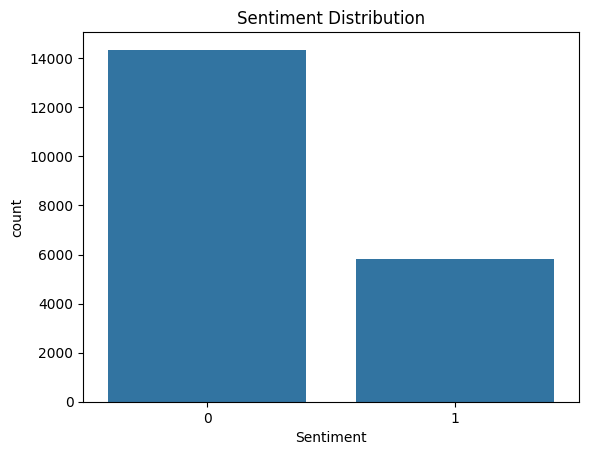

In [53]:
sns.countplot(x='Sentiment', data=df_cleaned)
plt.title("Sentiment Distribution")
plt.show()

In [54]:
X = df_cleaned['Review Text']
y = df_cleaned['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformed X_train shape:", X_train_tfidf.shape)

TF-IDF transformed X_train shape: (16136, 5000)


Accuracy: 0.9258800198314329

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2870
           1       0.92      0.82      0.86      1164

    accuracy                           0.93      4034
   macro avg       0.92      0.89      0.91      4034
weighted avg       0.93      0.93      0.92      4034



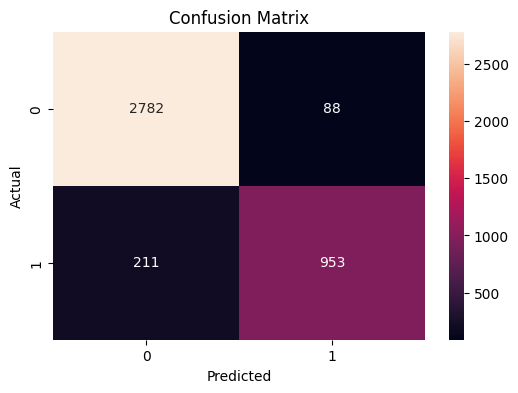

In [55]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

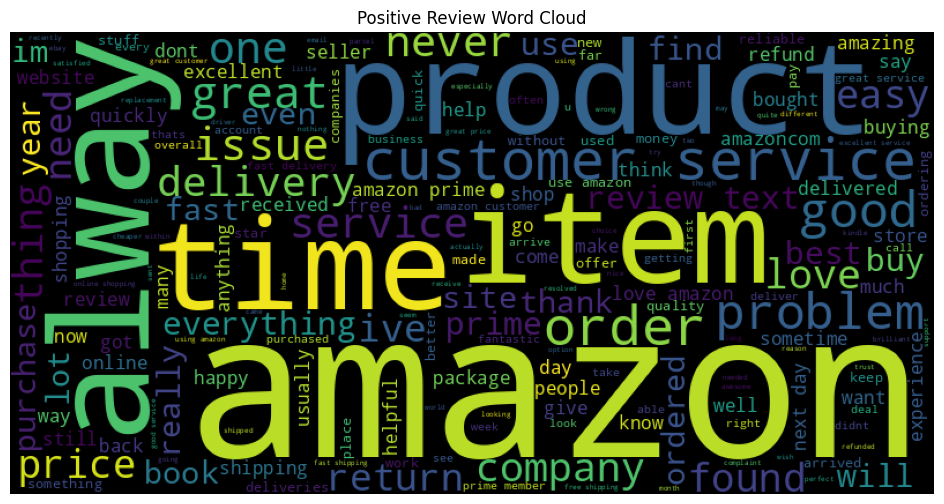

In [56]:
positive_reviews_text = " ".join(
    df_cleaned[df_cleaned['Sentiment']==1]['Review Text']
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(
    positive_reviews_text
)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

In [57]:
from google.colab import files

uploaded = files.upload()

Saving Amazon_Reviews.csv to Amazon_Reviews (1).csv


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud


In [59]:
df = pd.read_csv("Amazon_Reviews.csv", engine='python')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [60]:
print(df.columns)

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')


In [61]:
df = df.copy() # Ensure we are working on a standalone copy

df['Score'] = df['Rating'].str.extract(r'(\d+)').astype(float)
df.dropna(subset=['Score'], inplace=True)
df['Score'] = df['Score'].astype(int)

df = df[df['Score'] != 3].copy() # This copy is now mostly redundant but harmless after the first .copy()

df['Sentiment'] = df['Score'].apply(
    lambda x: 1 if x > 3 else 0
)

df[['Rating', 'Score','Sentiment']].head()

,Rating,Score,Sentiment
0,Rated 1 out of 5 stars,1,0
1,Rated 1 out of 5 stars,1,0
2,Rated 1 out of 5 stars,1,0
3,Rated 1 out of 5 stars,1,0
4,Rated 1 out of 5 stars,1,0


In [62]:
df = df[['Review Text','Sentiment']].copy()

df.dropna(inplace=True)

print(df.shape)

(20170, 2)


In [63]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df['Review Text'] = df['Review Text'].apply(clean_text)

df.head()

,Review Text,Sentiment
0,i registered on the website tried to order a l...,0
1,had multiple orders one turned up and driver h...,0
2,i informed these reprobates that i would not b...,0
3,i have bought from amazon before and no proble...,0
4,if i could give a lower rate i would i cancell...,0


In [64]:
# Display the first few rows of the preprocessed DataFrame
display(df.head())

,Review Text,Sentiment
0,i registered on the website tried to order a l...,0
1,had multiple orders one turned up and driver h...,0
2,i informed these reprobates that i would not b...,0
3,i have bought from amazon before and no proble...,0
4,if i could give a lower rate i would i cancell...,0


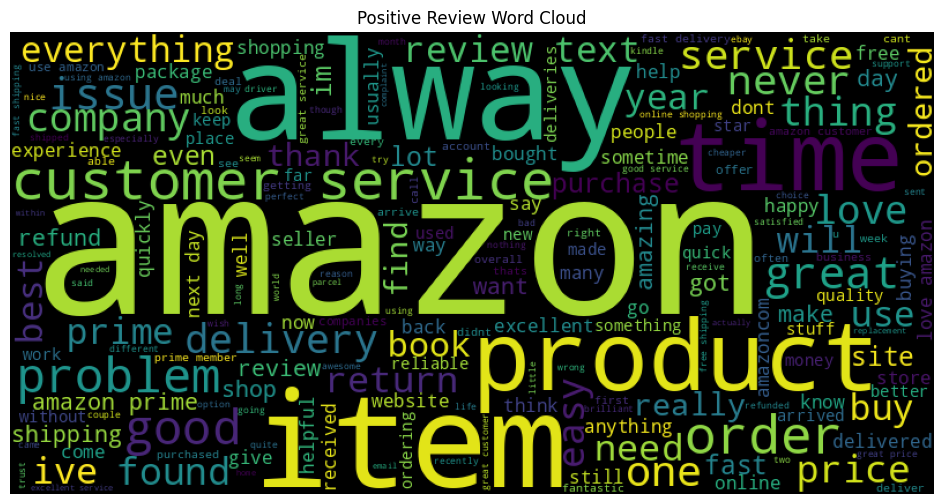

In [65]:
positive_reviews = " ".join(
    df[df['Sentiment']==1]['Review Text']
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(
    positive_reviews
)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Review Word Cloud")

plt.show()

In [29]:
df = pd.read_csv("Amazon_Reviews.csv", engine='python')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [30]:
print(df.columns)

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')


In [31]:
df = df.copy() # Ensure we are working on a standalone copy

df['Score'] = df['Rating'].str.extract(r'(\d+)').astype(float)
df.dropna(subset=['Score'], inplace=True)
df['Score'] = df['Score'].astype(int)

df = df[df['Score'] != 3].copy() # This copy is now mostly redundant but harmless after the first .copy()

df['Sentiment'] = df['Score'].apply(
    lambda x: 1 if x > 3 else 0
)

df[['Rating', 'Score','Sentiment']].head()

,Rating,Score,Sentiment
0,Rated 1 out of 5 stars,1,0
1,Rated 1 out of 5 stars,1,0
2,Rated 1 out of 5 stars,1,0
3,Rated 1 out of 5 stars,1,0
4,Rated 1 out of 5 stars,1,0


In [32]:
df = df[['Review Text','Sentiment']].copy()

df.dropna(inplace=True)

print(df.shape)

(20170, 2)


In [33]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df['Review Text'] = df['Review Text'].apply(clean_text)

df.head()

,Review Text,Sentiment
0,i registered on the website tried to order a l...,0
1,had multiple orders one turned up and driver h...,0
2,i informed these reprobates that i would not b...,0
3,i have bought from amazon before and no proble...,0
4,if i could give a lower rate i would i cancell...,0


In [34]:
df = pd.read_csv("Amazon_Reviews.csv", engine='python')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [36]:
df = df.copy() # Ensure we are working on a standalone copy

df['Score'] = df['Rating'].str.extract(r'(\d+)').astype(float)
df.dropna(subset=['Score'], inplace=True)
df['Score'] = df['Score'].astype(int)

df = df[df['Score'] != 3].copy() # This copy is now mostly redundant but harmless after the first .copy()

df['Sentiment'] = df['Score'].apply(
    lambda x: 1 if x > 3 else 0
)

df[['Rating', 'Score','Sentiment']].head()

,Rating,Score,Sentiment
0,Rated 1 out of 5 stars,1,0
1,Rated 1 out of 5 stars,1,0
2,Rated 1 out of 5 stars,1,0
3,Rated 1 out of 5 stars,1,0
4,Rated 1 out of 5 stars,1,0


In [37]:
df = df[['Review Text','Sentiment']].copy()

df.dropna(inplace=True)

print(df.shape)

(20170, 2)


In [19]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df['Review Text'] = df['Review Text'].apply(clean_text)

df.head()

,Review Text,Sentiment
0,i registered on the website tried to order a l...,0
1,had multiple orders one turned up and driver h...,0
2,i informed these reprobates that i would not b...,0
3,i have bought from amazon before and no proble...,0
4,if i could give a lower rate i would i cancell...,0


In [48]:
# Display the first few rows of the preprocessed DataFrame
display(df.head())

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


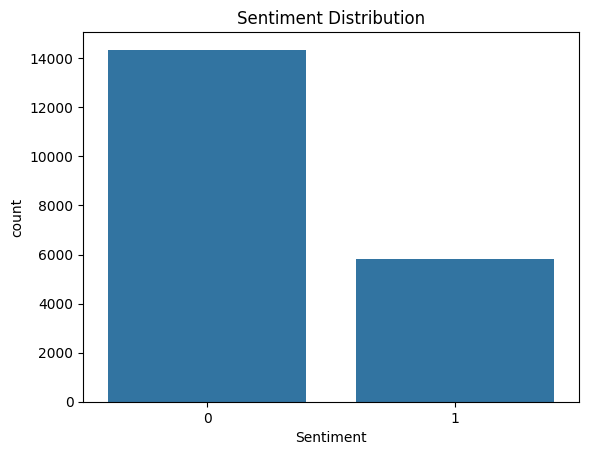

In [20]:
sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")
plt.show()

In [25]:
X = df['Review Text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(16136, 5000)


In [26]:
model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [27]:
y_pred = model.predict(X_test_tfidf)

In [28]:
acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", acc)

Accuracy: 0.9258800198314329


In [29]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2870
           1       0.92      0.82      0.86      1164

    accuracy                           0.93      4034
   macro avg       0.92      0.89      0.91      4034
weighted avg       0.93      0.93      0.92      4034



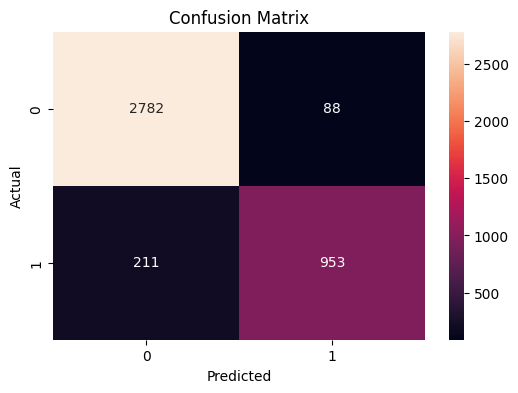

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [1]:
!pip install wordcloud

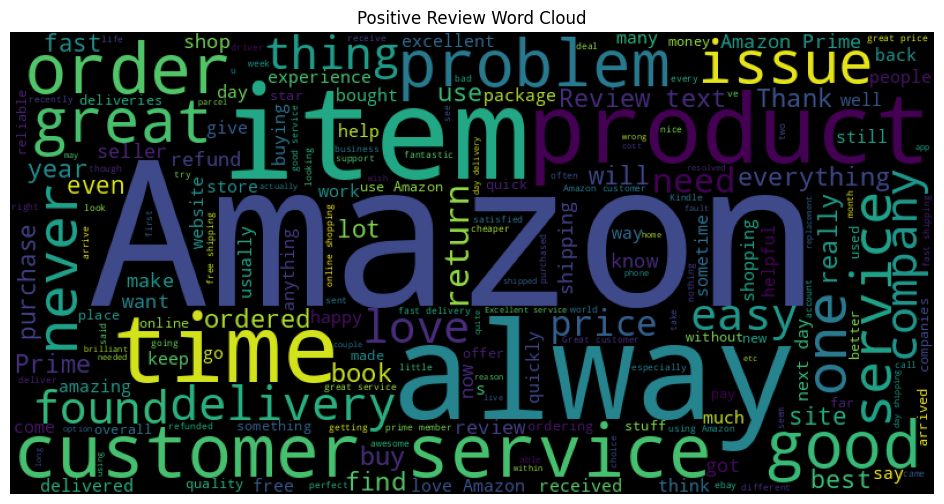

In [39]:
from wordcloud import WordCloud

positive_reviews = " ".join(
    df[df['Sentiment']==1]['Review Text']
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(
    positive_reviews
)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Review Word Cloud")

plt.show()

In [12]:
import os

# List all files and directories in the current working directory
files_in_directory = os.listdir('.')

print("Files in current directory:")
for f in files_in_directory:
    print(f)

Files in current directory:
.config
sample_data


In [66]:
sample_review = [
    "This product is excellent and works perfectly"
]

sample_vector = tfidf.transform(
    sample_review
)

prediction = model.predict(
    sample_vector
)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [67]:
import pickle

pickle.dump(
    model,
    open("sentiment_model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("tfidf.pkl","wb")
)

print("Model Saved")

Model Saved


Developed an NLP-based Amazon Product Review Sentiment Analysis system using Python, TF-IDF, and Logistic Regression, achieving high accuracy in classifying customer reviews as positive or negative